# Cost Function for Logistic Regression

## Goals
Implement the full logistic regression cost function using multiple features, and use it to compare two candidate models.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#sigmoid_funtion
def sigmoid(z):
    g = 1/(1+np.exp(-z))
    return np.clip(g,1e-10, 1 - 1e-10)  #force to tay in boundaries

In [2]:
X_train = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

## Dataset
Same dataset as the decision boundary lab.

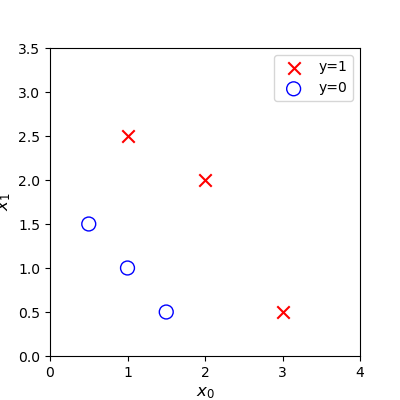

In [3]:
def plot_data(X, y, ax):
    y_flat = y.flatten() if y.ndim > 1 else y
    pos = y_flat == 1
    neg = y_flat == 0
    ax.scatter(X[pos, 0], X[pos, 1], marker='x', s=80, c='red', label='y=1')
    ax.scatter(X[neg, 0], X[neg, 1], marker='o', s=100, facecolors='none', edgecolors='blue', label='y=0')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_data(X_train, y_train, ax)
ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$', fontsize=12)
ax.set_xlabel('$x_0$', fontsize=12)
ax.legend()
plt.savefig("cost_fn_data.png")
plt.close()

from IPython.display import Image
Image("cost_fn_data.png")

In [6]:
def compute_cost_logistic(x,y,w,b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(x[i],w)+b
        f_wb_i = sigmoid(z_i)
        cost+= -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)
    cost = cost/m
    return cost

In [7]:
w_tmp = np.array([1,1])
b = -3
print(compute_cost_logistic(X_train,y_train,w_tmp,b))

0.36686678640551745


## Example
Let's compare two candidate models: b=-3 vs b=-4 (same w=[1,1]), and see which one the cost function correctly identifies as better.